# Adult Census Income: предсказание уровня дохода

Цель проекта - построить классический ML-пайплайн для бинарной классификации: предсказать, превышает ли годовой доход человека 50 000 долларов.

По умолчанию notebook использует уже сохранённые результаты `GridSearchCV` и финальную модель. Если нужно пересчитать всё с нуля, переключите флаги `RUN_MODEL_COMPARISON` и `RUN_GRIDSEARCH` в первой code-ячейке.

## 1. Импорты и настройки

In [1]:
import os

os.environ.setdefault("LOKY_MAX_CPU_COUNT", "1")

import pandas as pd
from sklearn.metrics import classification_report

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT / "src"))

from adult_income_utils import (
    RANDOM_STATE,
    get_cleaning_summary,
    prepare_model_data,
    make_preprocessor,
)
from adult_modeling import (
    compare_models_cv,
    choose_top_models,
    error_summary_by_column,
    evaluate_estimator,
    fit_model_pipelines,
    get_model_explanation,
    get_scoring_metrics,
    load_final_model,
    load_final_report,
    load_model_comparison,
    load_top_models,
    make_cv,
    make_models,
    make_rankings,
    make_results_summary,
    make_error_frame,
    save_final_artifacts,
    save_model_comparison,
    select_best_grid,
    tune_models,
)
from adult_visualization import (
    configure_plots,
    plot_capital_by_income,
    plot_correlation_heatmap,
    plot_final_evaluation,
    plot_high_income_rate,
    plot_model_comparison,
    plot_numeric_by_income,
    plot_numeric_distributions,
    plot_rankings_heatmap,
    plot_target_distribution,
    plot_top_features,
    target_distribution,
)

pd.set_option("display.max_columns", 120)
configure_plots()

RUN_MODEL_COMPARISON = False
RUN_GRIDSEARCH = False

RANDOM_STATE

42

## 2. Загрузка и очистка данных

Используются локальные файлы `adult.data` и `adult.test`. В очистке выполняются:

- ручное назначение имён колонок;
- удаление лишних пробелов в строковых значениях;
- замена `?` на `NaN`;
- нормализация target в `adult.test`, где значения имеют точку на конце;
- удаление полных дубликатов.

Пропуски не удаляются: они обрабатываются через `SimpleImputer`.

In [2]:
cleaning_summary = get_cleaning_summary()

print("Train shape:", cleaning_summary["train_shape"])
print("Test shape:", cleaning_summary["test_shape"])
print("Raw combined shape:", cleaning_summary["raw_shape"])
print("Clean shape:", cleaning_summary["clean_shape"])
print("Rows with at least one missing value:", cleaning_summary["rows_with_missing"])
print("Full duplicate rows:", cleaning_summary["duplicate_count"])

cleaning_summary["missing_summary"]

Train shape: (32561, 15)
Test shape: (16281, 15)
Raw combined shape: (48842, 15)
Clean shape: (48790, 15)
Rows with at least one missing value: 3620
Full duplicate rows: 52


,missing_count,missing_percent
occupation,2809,5.751198
workclass,2799,5.730724
native_country,857,1.754637


## 3. EDA

Для EDA пропуски временно показываются как категория `Unknown`, чтобы неизвестные значения были видны на графиках. Это не заменяет preprocessing в модели.

In [3]:
data = prepare_model_data(random_state=RANDOM_STATE)

df_clean = data["df_clean"]
df_features = data["df_features"]
df_eda = df_clean.fillna("Unknown")

numeric_columns = df_eda.select_dtypes(include="number").columns.tolist()
categorical_columns = df_eda.select_dtypes(include="object").columns.tolist()

print("Clean data shape:", df_clean.shape)
print("Numeric columns:", numeric_columns)
print("Categorical columns:", categorical_columns)

target_distribution(df_eda)

Clean data shape: (48790, 15)
Numeric columns: ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
Categorical columns: ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country', 'income']


,count,percent
income,,
<=50K,37109,76.058619
>50K,11681,23.941381


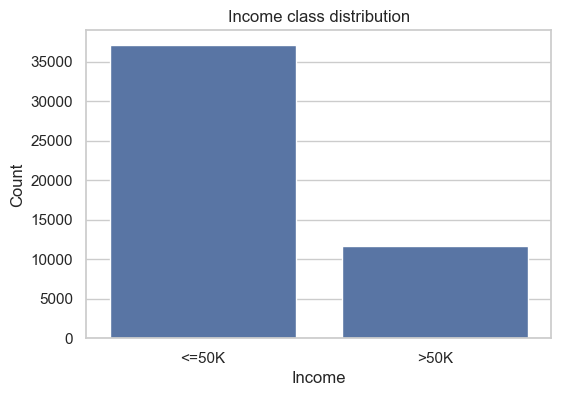

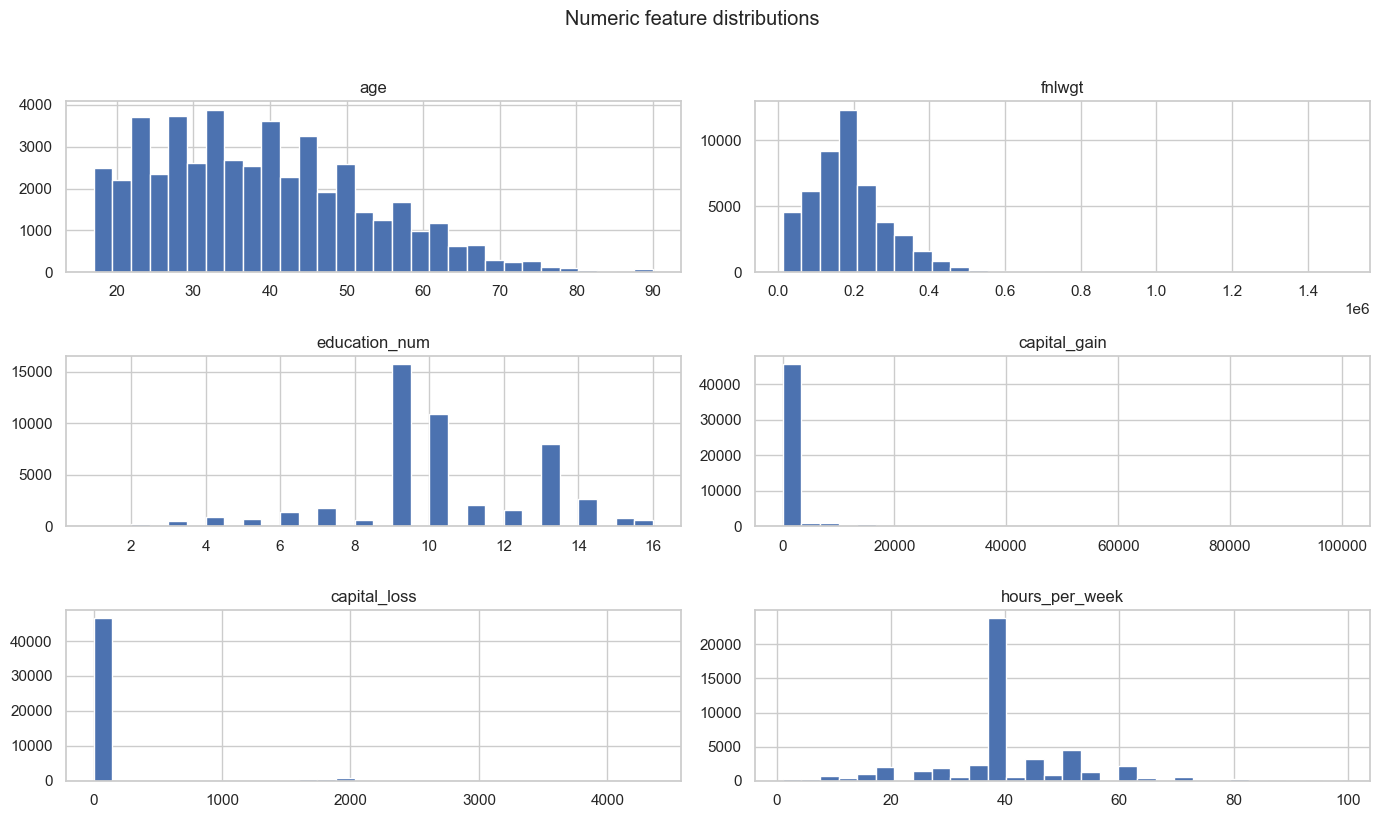

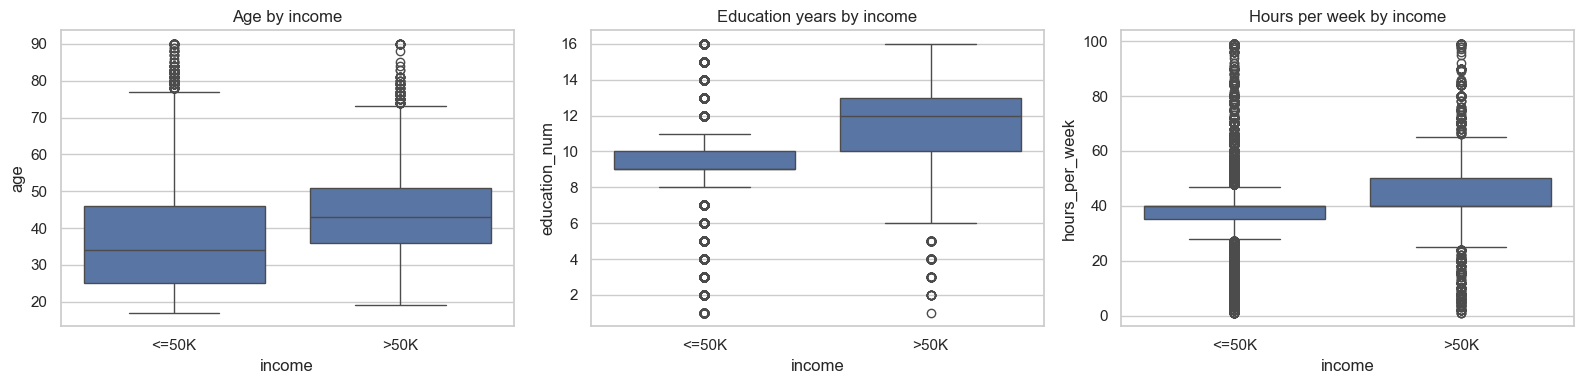

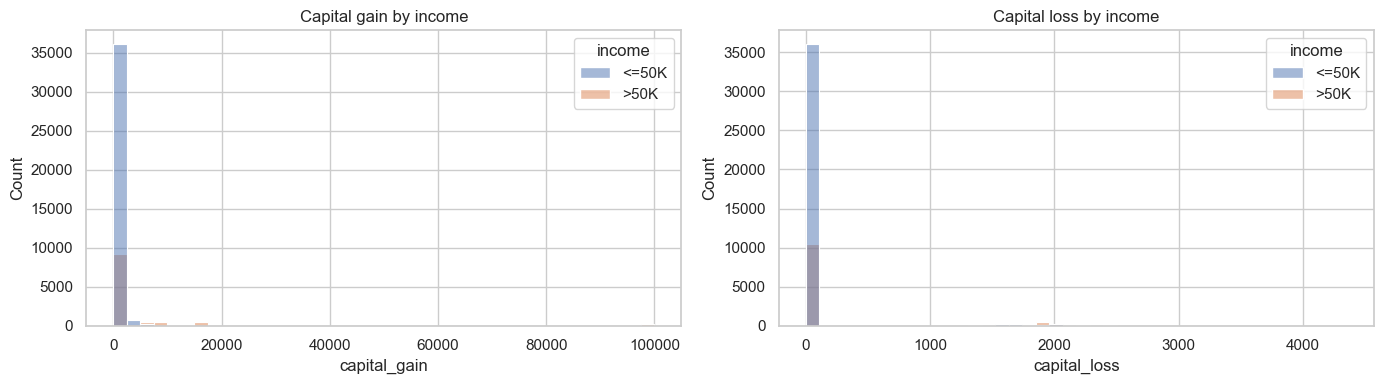

In [4]:
plot_target_distribution(df_eda)
plot_numeric_distributions(df_eda, numeric_columns)
plot_numeric_by_income(df_eda)
plot_capital_by_income(df_eda)

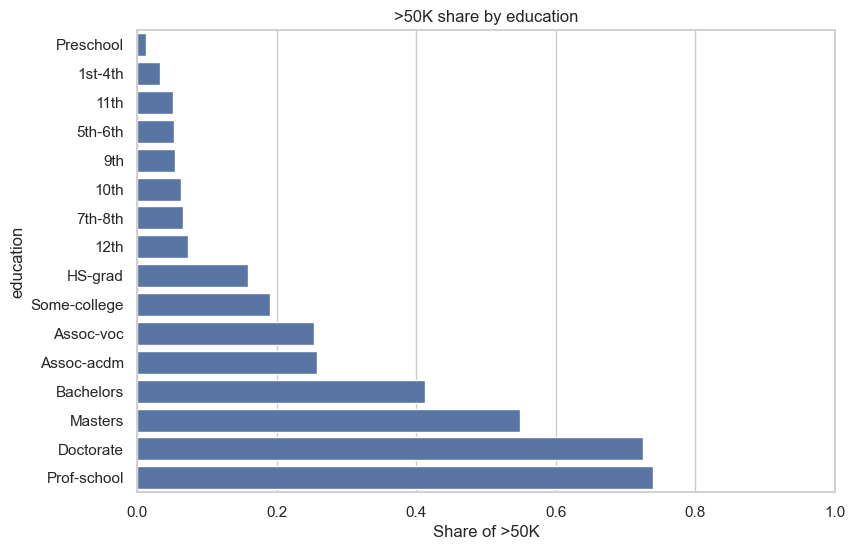

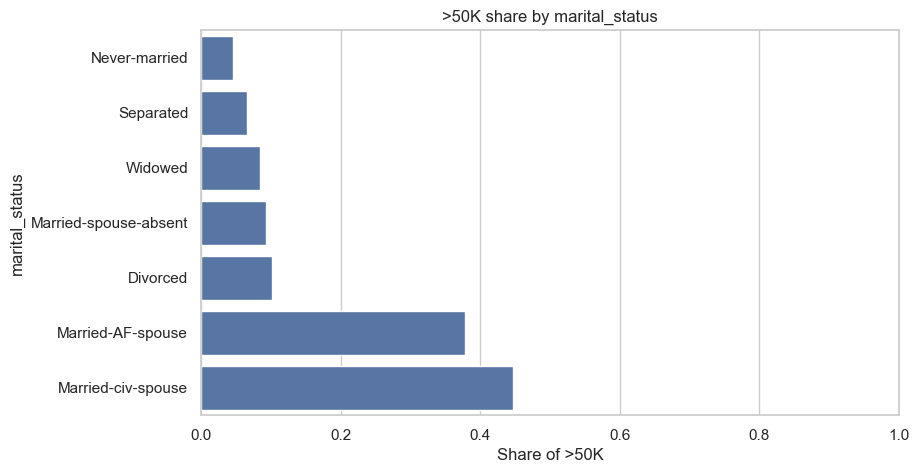

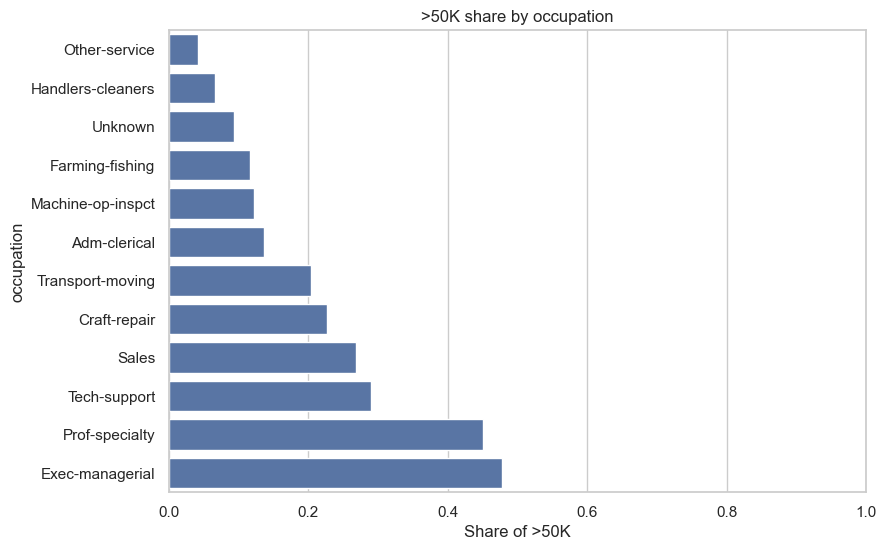

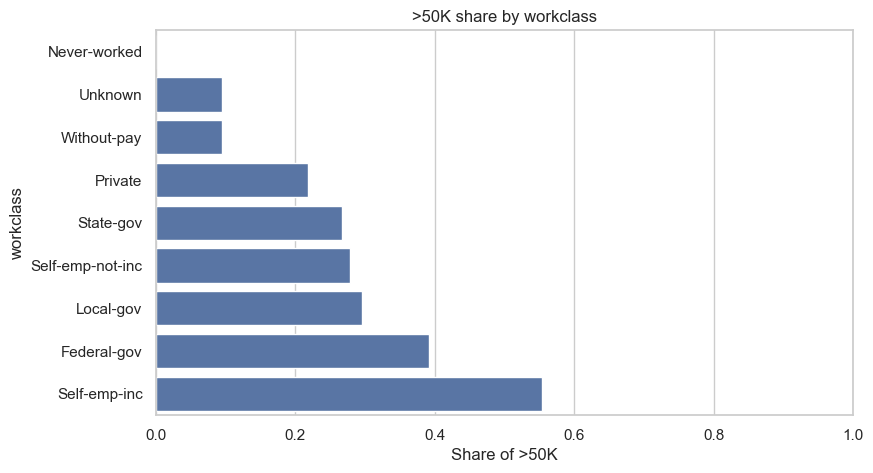

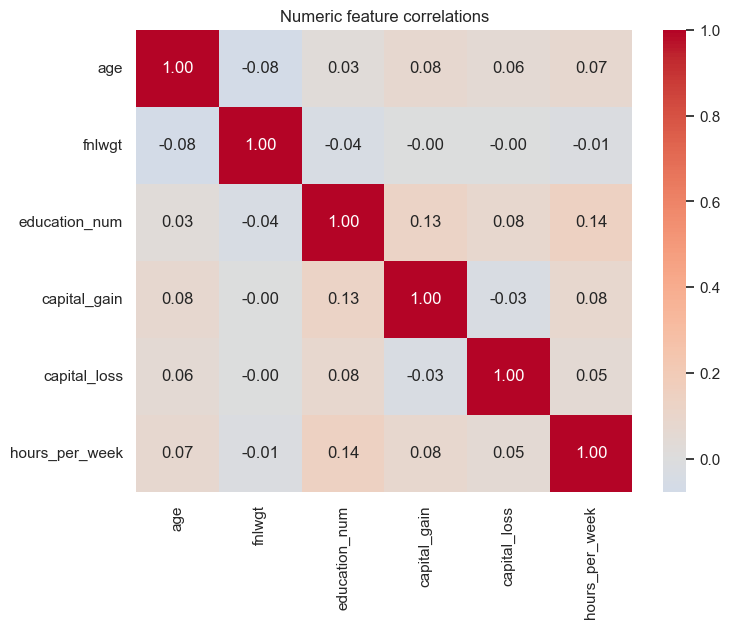

In [5]:
plot_high_income_rate(df_eda, "education", figsize=(9, 6))
plot_high_income_rate(df_eda, "marital_status", figsize=(9, 5))
plot_high_income_rate(df_eda, "occupation", top_n=12, figsize=(9, 6))
plot_high_income_rate(df_eda, "workclass", figsize=(9, 5))
plot_correlation_heatmap(df_eda, numeric_columns)

Основные выводы EDA:

- классы несбалансированы, поэтому accuracy недостаточно;
- образование, семейный статус, профессия и рабочие часы связаны с долей `>50K`;
- `capital_gain` и `capital_loss` сильно скошены и часто равны нулю;
- нужны разные preprocessing-шаги для числовых и категориальных признаков.

## 4. Feature engineering

Добавлены только понятные и защищаемые признаки:

- `is_married`;
- `native_country_group`;
- `workclass_group`;
- `hours_per_week_bin`;
- `capital_net`;
- `has_capital_gain`;
- `has_capital_loss`.

Исходные признаки сохраняются.

In [6]:
engineered_features = [
    "is_married",
    "native_country_group",
    "workclass_group",
    "hours_per_week_bin",
    "capital_net",
    "has_capital_gain",
    "has_capital_loss",
]

print("Shape before feature engineering:", df_clean.shape)
print("Shape after feature engineering:", df_features.shape)

df_features[engineered_features].head()

Shape before feature engineering: (48790, 15)
Shape after feature engineering: (48790, 22)


,is_married,native_country_group,workclass_group,hours_per_week_bin,capital_net,has_capital_gain,has_capital_loss
0,0,United-States,Government,full_time_40,2174,1,0
1,1,United-States,Self-employed,part_time,0,0,0
2,0,United-States,Private,full_time_40,0,0,0
3,1,United-States,Private,full_time_40,0,0,0
4,1,Other,Private,full_time_40,0,0,0


## 5. Train/test split и preprocessing

Данные разделяются через `train_test_split(..., stratify=y, random_state=42)`, чтобы сохранить пропорции классов.

Preprocessing:

- числовые признаки: `SimpleImputer(strategy="median")` + `StandardScaler`;
- категориальные признаки: `SimpleImputer(strategy="constant", fill_value="Unknown")` + `OneHotEncoder(handle_unknown="ignore")`.

Все preprocessing-шаги находятся внутри `Pipeline`, чтобы избежать leakage.

In [7]:
X = data["X"]
y = data["y"]
X_train = data["X_train"]
X_test = data["X_test"]
y_train = data["y_train"]
y_test = data["y_test"]
numerical_features = data["numerical_features"]
categorical_features = data["categorical_features"]

class_balance = pd.DataFrame({
    "full": y.value_counts(normalize=True).sort_index(),
    "train": y_train.value_counts(normalize=True).sort_index(),
    "test": y_test.value_counts(normalize=True).sort_index(),
})

print("X shape:", X.shape)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
display(class_balance)

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

X shape: (48790, 21)
X_train shape: (39032, 21)
X_test shape: (9758, 21)


,full,train,test
income,,,
0,0.760586,0.760581,0.760607
1,0.239414,0.239419,0.239393


Numerical features: ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week', 'is_married', 'capital_net', 'has_capital_gain', 'has_capital_loss']
Categorical features: ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country', 'native_country_group', 'workclass_group', 'hours_per_week_bin']


In [8]:
preprocessor = make_preprocessor(numerical_features, categorical_features)
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

print("Preprocessed train shape:", X_train_preprocessed.shape)
print("Preprocessed test shape:", X_test_preprocessed.shape)

Preprocessed train shape: (39032, 124)
Preprocessed test shape: (9758, 124)


## 6. Baseline и модели

Baseline - `DummyClassifier(strategy="most_frequent")`. Он не использует признаки и показывает нижнюю планку качества для несбалансированной задачи.

Основные модели:

- Logistic Regression;
- KNN;
- Decision Tree;
- Random Forest;
- Gradient Boosting.

In [9]:
models = make_models()
fitted_pipelines = fit_model_pipelines(
    X_train,
    y_train,
    numerical_features,
    categorical_features,
    models=models,
)

list(fitted_pipelines.keys())

['DummyClassifier',
 'LogisticRegression',
 'KNN',
 'DecisionTree',
 'RandomForest',
 'GradientBoosting']

## 7. Cross-validation и сравнение моделей

По умолчанию используются сохранённые результаты из `data/model_comparison_results.csv`. Чтобы пересчитать сравнение моделей, установите `RUN_MODEL_COMPARISON = True` в первой ячейке.

In [10]:
if RUN_MODEL_COMPARISON:
    comparison = compare_models_cv(
        X_train,
        y_train,
        numerical_features,
        categorical_features,
        models=models,
        cv=make_cv(),
        scoring=get_scoring_metrics(),
        n_jobs=1,
    )
    results_summary = comparison["results_summary"]
    rankings = comparison["rankings"]
    top_model_names = comparison["top_model_names"]
    save_model_comparison(results_summary, rankings, top_model_names)
else:
    results_summary = load_model_comparison()
    rankings = make_rankings(results_summary)
    top_model_names = load_top_models()

display(results_summary.round(4))
display(rankings.round(2))
print("Top models:", top_model_names)

,Accuracy,F1,Balanced Accuracy,ROC-AUC,mean_rank
Model,,,,,
DummyClassifier,0.7606,0.0000,0.5000,0.5000,6.00
LogisticRegression,0.8136,0.6854,0.8255,0.9103,2.00
KNN,0.8363,0.6451,0.7627,0.8624,3.75
DecisionTree,0.8131,0.6120,0.7454,0.7454,5.00
RandomForest,0.8537,0.6649,0.7690,0.9025,2.75
GradientBoosting,0.8651,0.6818,0.7755,0.9202,1.50


,Accuracy_rank,F1_rank,Balanced Accuracy_rank,ROC-AUC_rank,mean_rank
Model,,,,,
GradientBoosting,1,2,2,1,1.50
LogisticRegression,4,1,1,2,2.00
RandomForest,2,3,3,3,2.75
KNN,3,4,4,4,3.75
DecisionTree,5,5,5,5,5.00
DummyClassifier,6,6,6,6,6.00


Top models: ['GradientBoosting', 'LogisticRegression']


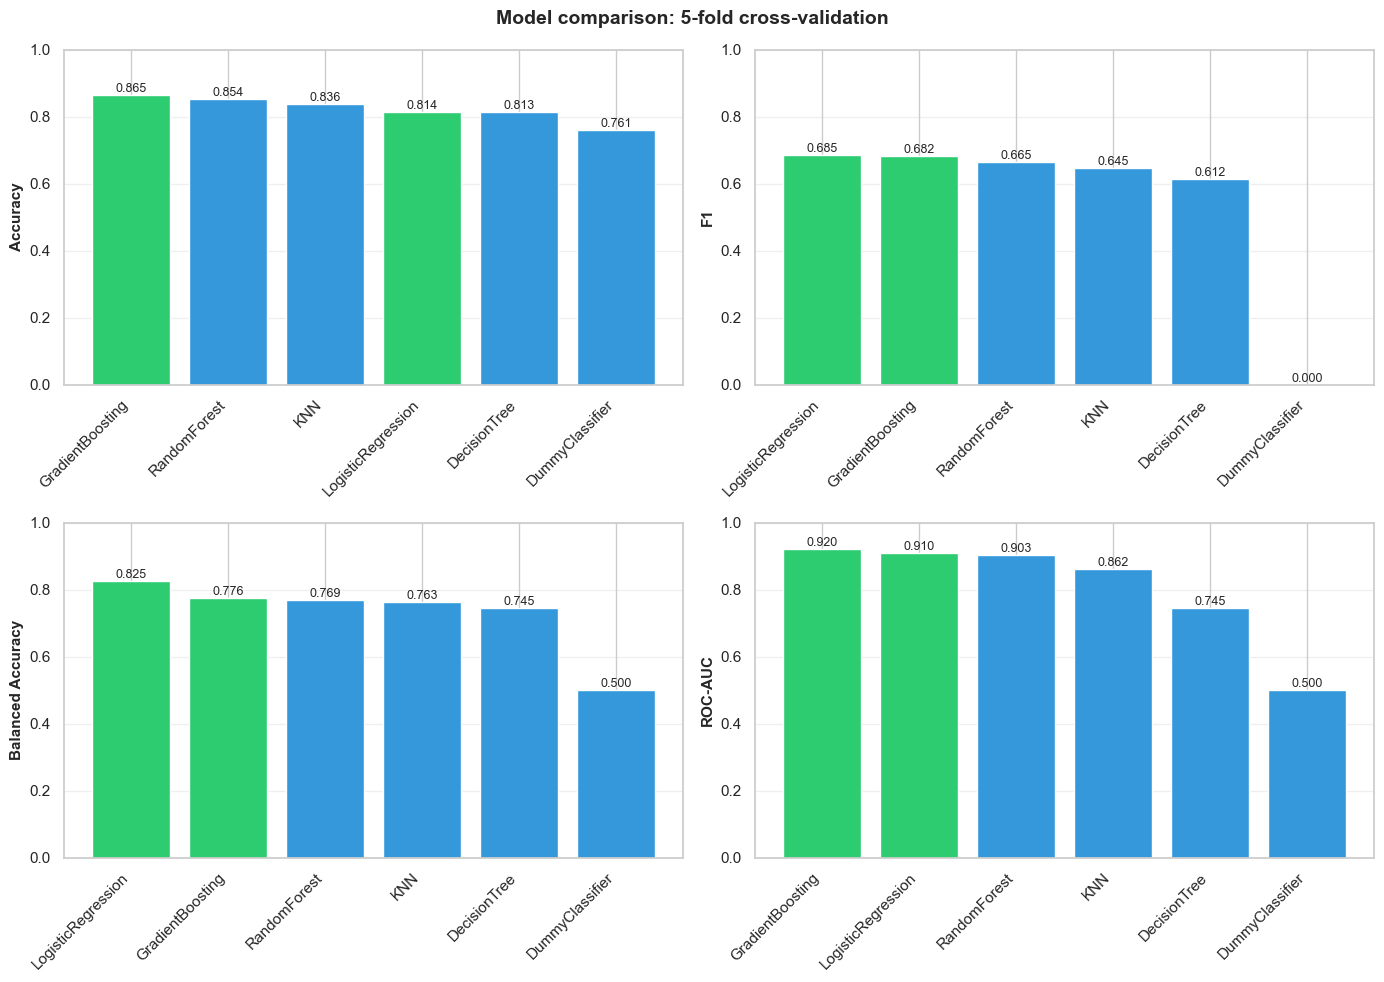

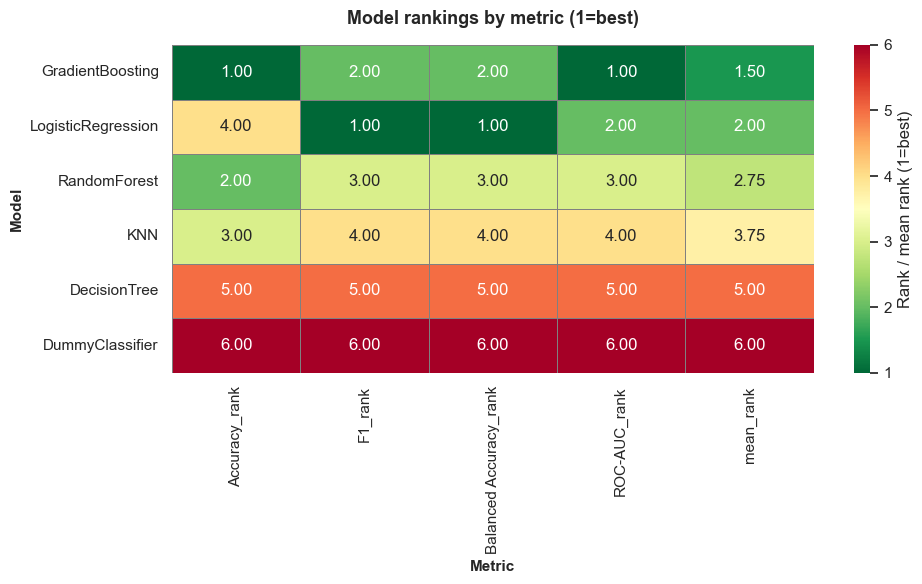

In [11]:
plot_model_comparison(results_summary, top_model_names)
plot_rankings_heatmap(rankings)

По сохранённому сравнению лучшие кандидаты для настройки - `GradientBoosting` и `LogisticRegression`. Gradient Boosting показывает лучший ROC-AUC и accuracy, Logistic Regression сильнее по F1 и balanced accuracy.

## 8. GridSearchCV и финальная модель

По умолчанию notebook загружает уже сохранённую финальную модель из `data/best_model_gridsearch.joblib`. Чтобы заново выполнить GridSearchCV, установите `RUN_GRIDSEARCH = True`.

In [12]:
if RUN_GRIDSEARCH:
    gridsearch_results, gridsearch_summary_df = tune_models(
        top_model_names,
        X_train,
        y_train,
        numerical_features,
        categorical_features,
        models=models,
        cv=make_cv(),
        scoring=get_scoring_metrics(),
        refit_metric="roc_auc",
        n_jobs=1,
        verbose=1,
    )
    best_model_name, best_grid, final_model = select_best_grid(
        gridsearch_results,
        gridsearch_summary_df,
        refit_metric="roc_auc",
    )
    evaluation = evaluate_estimator(final_model, X_test, y_test)
    save_final_artifacts(
        final_model,
        best_model_name,
        best_grid,
        evaluation["metrics"],
        top_model_names,
        refit_metric="roc_auc",
    )
else:
    final_model = load_final_model()
    final_report = load_final_report()
    best_model_name = final_report["best_model"]
    evaluation = evaluate_estimator(final_model, X_test, y_test)

print("Final model:", best_model_name)
pd.DataFrame([evaluation["metrics"]]).T.rename(columns={0: "value"})

Final model: GradientBoosting


,value
accuracy,0.876512
precision,0.792550
recall,0.655822
f1,0.717732
balanced_accuracy,0.800897
roc_auc,0.929375


              precision    recall  f1-score   support

           0       0.90      0.95      0.92      7422
           1       0.79      0.66      0.72      2336

    accuracy                           0.88      9758
   macro avg       0.84      0.80      0.82      9758
weighted avg       0.87      0.88      0.87      9758



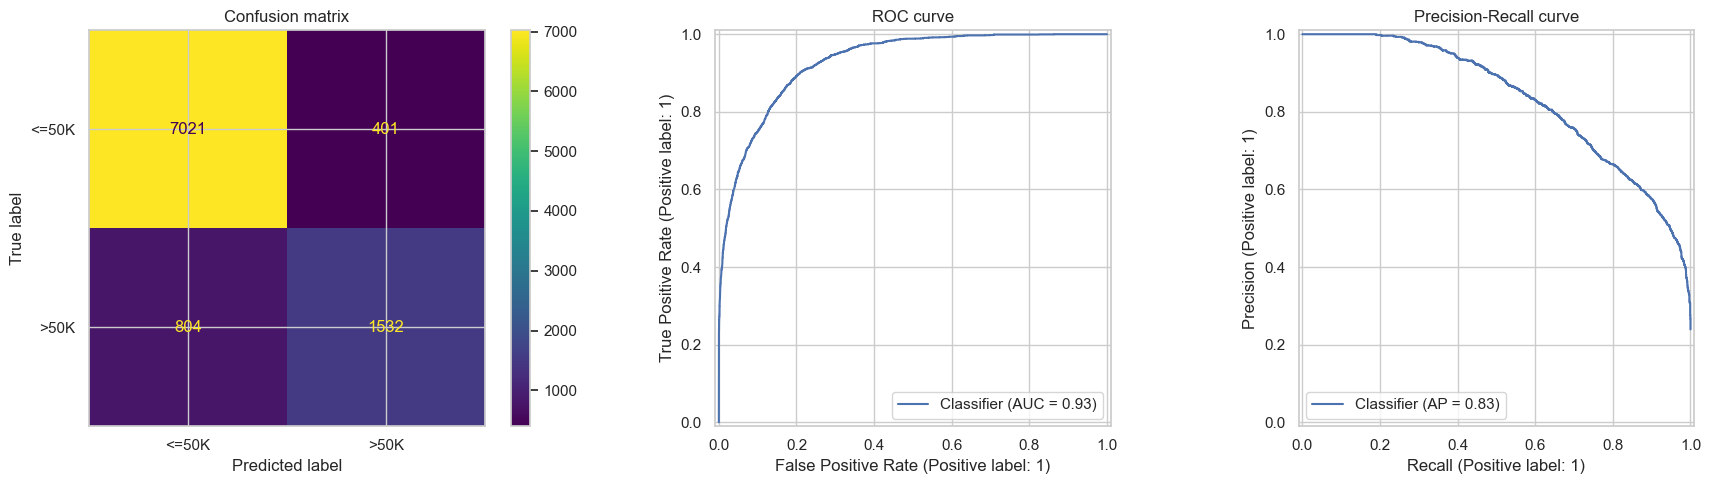

In [13]:
print(evaluation["classification_report"])
plot_final_evaluation(y_test, evaluation["y_pred"], evaluation["y_score"])

## 9. Интерпретация модели

Для Gradient Boosting и Random Forest используем `feature_importances_`. Для Logistic Regression используются коэффициенты модели.

,feature,importance
6,num__is_married,0.375648
2,num__education_num,0.189927
7,num__capital_net,0.136572
3,num__capital_gain,0.092451
0,num__age,0.058502
4,num__capital_loss,0.034594
5,num__hours_per_week,0.031539
45,cat__occupation_Exec-managerial,0.015365
51,cat__occupation_Prof-specialty,0.009048
123,cat__hours_per_week_bin_part_time,0.007694


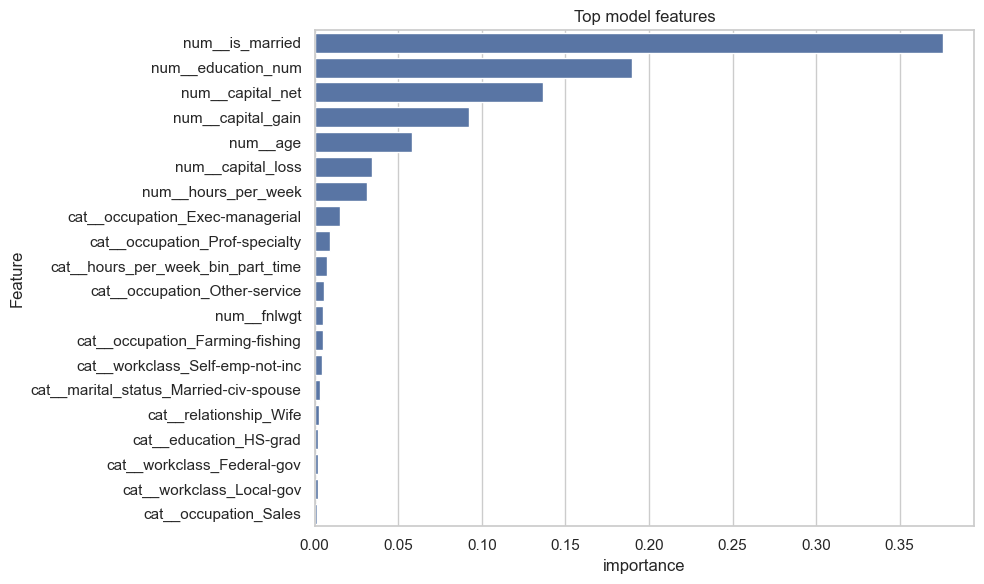

In [14]:
feature_table, value_column = get_model_explanation(final_model, top_n=20)

display(feature_table)
if value_column is not None and not feature_table.empty:
    plot_top_features(feature_table, value_column)

## 10. Анализ ошибок

Смотрим false positives и false negatives. Это помогает понять, на каких группах модель чаще ошибается.

In [15]:
error_df = make_error_frame(
    X_test,
    y_test,
    evaluation["y_pred"],
    evaluation["y_score"],
)

display(error_df["error_type"].value_counts())
display(error_df[error_df["error_type"] == "false_positive"].head())
display(error_df[error_df["error_type"] == "false_negative"].head())

error_type
correct           8553
false_negative     804
false_positive     401
Name: count, dtype: int64

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,is_married,native_country_group,workclass_group,hours_per_week_bin,capital_net,has_capital_gain,has_capital_loss,true,pred,score_>50K,error_type
21627,45,Private,357540,Bachelors,13,Married-civ-spouse,Sales,Husband,White,Male,0,2002,55,United-States,1,United-States,Private,extreme,-2002,0,1,0,1,0.608417,false_positive
34886,42,Private,111589,Assoc-voc,11,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States,1,United-States,Private,full_time_40,0,0,0,0,1,0.546768,false_positive
46384,38,Private,213512,Some-college,10,Married-civ-spouse,Sales,Husband,White,Male,0,0,50,United-States,1,United-States,Private,over_40,0,0,0,0,1,0.538222,false_positive
10976,35,Federal-gov,105138,Prof-school,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,55,United-States,1,United-States,Government,extreme,0,0,0,0,1,0.888571,false_positive
14228,40,Private,77975,Some-college,10,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States,1,United-States,Private,full_time_40,0,0,0,0,1,0.510561,false_positive


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,is_married,native_country_group,workclass_group,hours_per_week_bin,capital_net,has_capital_gain,has_capital_loss,true,pred,score_>50K,error_type
24274,43,State-gov,164790,Some-college,10,Divorced,Adm-clerical,Not-in-family,Black,Male,0,0,50,United-States,0,United-States,Government,over_40,0,0,0,1,0,0.085848,false_negative
19263,26,Private,169121,Bachelors,13,Married-civ-spouse,Sales,Husband,White,Male,0,0,48,United-States,1,United-States,Private,over_40,0,0,0,1,0,0.370872,false_negative
45277,47,Private,101825,HS-grad,9,Married-civ-spouse,Adm-clerical,Wife,White,Female,0,0,40,United-States,1,United-States,Private,full_time_40,0,0,0,1,0,0.334213,false_negative
25872,40,Private,445382,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States,1,United-States,Private,full_time_40,0,0,0,1,0,0.487966,false_negative
35517,28,Private,108706,HS-grad,9,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,40,United-States,1,United-States,Private,full_time_40,0,0,0,1,0,0.243706,false_negative


In [16]:
for column in ["education", "marital_status", "occupation", "workclass_group", "hours_per_week_bin"]:
    print("\n" + "=" * 80)
    print(column)
    display(error_summary_by_column(error_df, column).head(10))


education


error_type,correct,false_negative,false_positive
education,,,
Doctorate,0.776,0.140,0.084
HS-grad,0.882,0.110,0.008
Assoc-voc,0.853,0.107,0.040
Masters,0.823,0.093,0.084
Bachelors,0.822,0.074,0.104
Some-college,0.888,0.072,0.040
10th,0.935,0.065,0.000
5th-6th,0.941,0.059,0.000
Assoc-acdm,0.848,0.057,0.095



marital_status


error_type,correct,false_negative,false_positive
marital_status,,,
Married-civ-spouse,0.777,0.134,0.089
Married-AF-spouse,0.750,0.125,0.125
Divorced,0.935,0.064,0.001
Widowed,0.944,0.056,0.000
Separated,0.954,0.046,0.000
Married-spouse-absent,0.968,0.032,0.000
Never-married,0.974,0.025,0.001



occupation


error_type,correct,false_negative,false_positive
occupation,,,
Craft-repair,0.828,0.146,0.026
Transport-moving,0.844,0.125,0.031
Protective-serv,0.829,0.110,0.061
Farming-fishing,0.904,0.093,0.003
Tech-support,0.851,0.091,0.058
Exec-managerial,0.819,0.087,0.094
Sales,0.869,0.078,0.053
Machine-op-inspct,0.923,0.074,0.003
Adm-clerical,0.902,0.074,0.024



workclass_group


error_type,correct,false_negative,false_positive
workclass_group,,,
Self-employed,0.824,0.113,0.062
Private,0.888,0.081,0.032
Government,0.840,0.079,0.080
Unknown,0.929,0.052,0.019
Other,0.750,0.000,0.250



hours_per_week_bin


error_type,correct,false_negative,false_positive
hours_per_week_bin,,,
extreme,0.810,0.109,0.081
over_40,0.820,0.103,0.077
full_time_40,0.883,0.083,0.034
part_time,0.953,0.044,0.003


## 11. Итоговые выводы

- Baseline преодолён по всем содержательным метрикам.
- Финальная модель - Gradient Boosting.
- Accuracy сама по себе недостаточна из-за дисбаланса классов.
- Для оценки используются F1, balanced accuracy, precision, recall и ROC-AUC.
- Важными группами признаков ожидаемо оказываются образование, семейный статус, capital-признаки, профессия и рабочие часы.
- Ограничения: датасет старый, отражает социально-экономический контекст 1994 года и может содержать bias/fairness issues.